In [31]:
import os
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict

In [32]:
load_dotenv()

True

In [33]:
model = ChatOpenAI()

In [34]:
class LLM_State(TypedDict):
    question : str
    answer : str

In [35]:
graph = StateGraph(state_schema = LLM_State)

In [36]:
def get_llm_response(state:LLM_State)->LLM_State:
    question = state['question']
    prompt = f'can you answer the question {question}'
    answer = model.invoke(prompt).content
    state['answer'] = answer
    return state

In [ ]:
graph.add_node('get_llm_response',get_llm_response)
graph.add_edge(START,'get_llm_response')
graph.add_edge('get_llm_response',END)




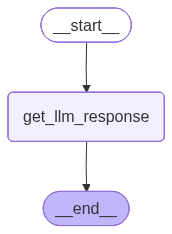

In [38]:
graph.compile()

In [39]:
workflow = graph.compile()

In [42]:
workflow.invoke(input={
    'question':'what is the distance between moon and earth?'
})

{'question': 'what is the distance between moon and earth?',
 'answer': 'The average distance between the Moon and Earth is about 384,400 kilometers (238,855 miles).'}